In [58]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

In [59]:
medic = pd.read_csv("insurance.csv")

In [60]:
medic

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


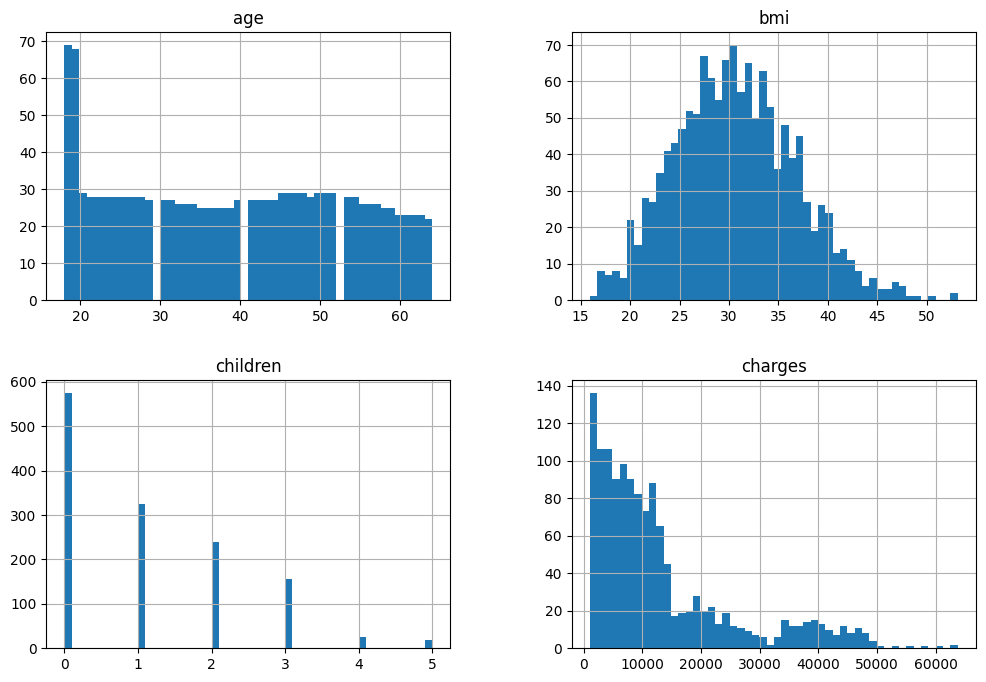

In [61]:
medic.hist(bins=50, figsize=(12, 8))
plt.show()

In [62]:
medic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [63]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(medic, medic["smoker"]):
    strat_train_set = medic.loc[train_index]
    strat_test_set = medic.loc[test_index]

print(f"\nSmoker Ratio in Full Data: {medic['smoker'].value_counts(normalize=True)['yes']:.2%}")
print(f"Smoker Ratio in Test Set:  {strat_test_set['smoker'].value_counts(normalize=True)['yes']:.2%}")


Smoker Ratio in Full Data: 20.48%
Smoker Ratio in Test Set:  20.52%


In [64]:
strat_train_set

,age,sex,bmi,children,smoker,region,charges
294,25,male,26.800,3,no,southwest,3906.12700
179,41,female,33.155,3,no,northeast,8538.28845
1335,18,female,36.850,0,no,southeast,1629.83350
634,51,male,39.700,1,no,southwest,9391.34600
67,40,male,26.315,1,no,northwest,6389.37785
...,...,...,...,...,...,...,...
627,33,male,42.460,1,no,southeast,11326.71487
76,29,female,29.590,1,no,southeast,3947.41310
319,32,male,37.335,1,no,northeast,4667.60765
197,45,female,28.600,2,no,southeast,8516.82900


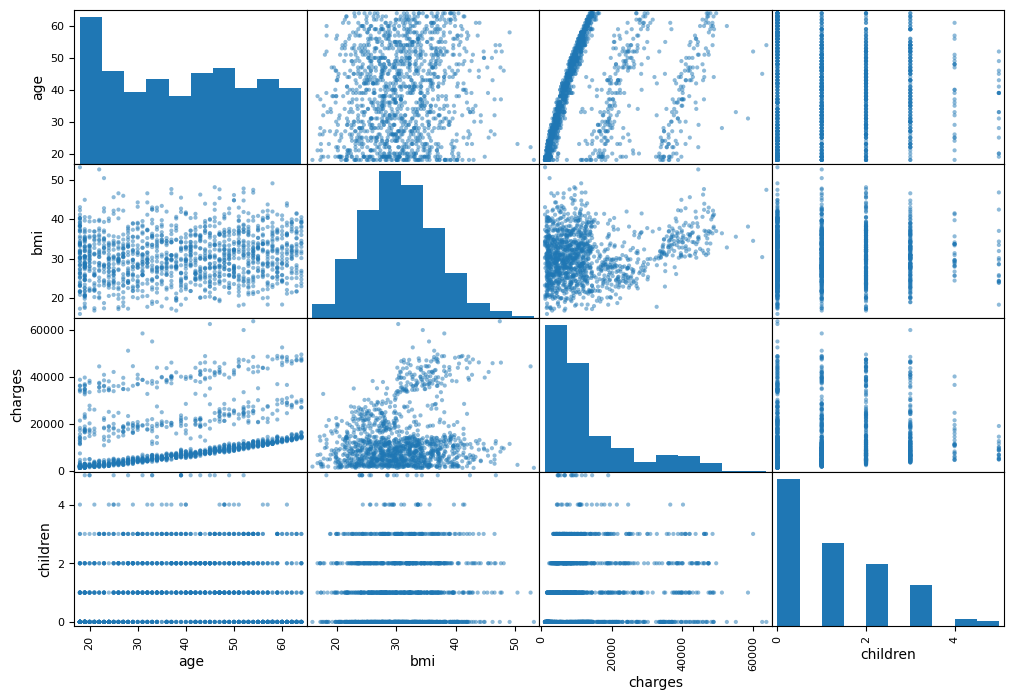

In [65]:
from pandas.plotting import scatter_matrix
attributes = ["age",
              "bmi",
              "charges",
              "children"]
scatter_matrix(medic[attributes], figsize=(12, 8))
plt.show()

In [66]:
medic_train = strat_train_set.drop("charges", axis=1)
medic_labels = strat_train_set["charges"].copy()

In [67]:
medic_labels_log = np.log1p(medic_labels)

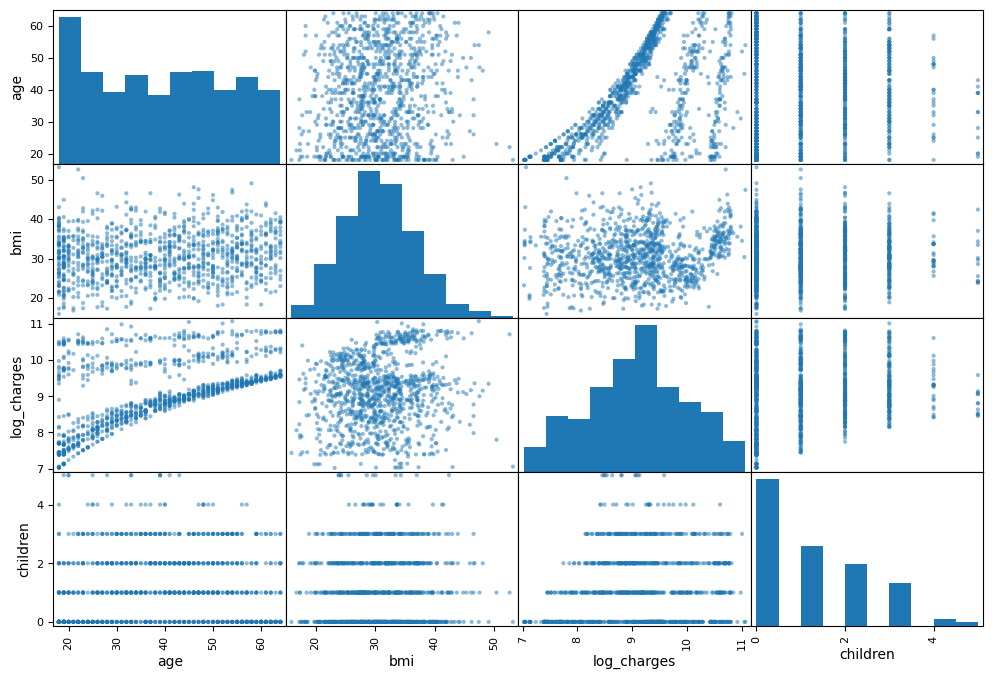

In [68]:
from pandas.plotting import scatter_matrix

medic_plotting = medic_train.copy()
medic_plotting["log_charges"] = medic_labels_log

attributes = ["age", "bmi", "log_charges", "children"]
scatter_matrix(medic_plotting[attributes], figsize=(12, 8))
plt.show()

In [69]:
medic

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [70]:
from sklearn.base import BaseEstimator, TransformerMixin

class MedicalFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # Expects a DataFrame with 'bmi', 'age', 'smoker'
        # We need to handle if X is a NumPy array (from previous steps) or DataFrame
        # Ideally, we put this at the START of the pipeline when X is still a DataFrame.
        
        X_out = X.copy()
        
        # 1. Convert smoker to numeric for math (yes=1, no=0)
        # We assume 'smoker' column exists. If strictly pipeline, we might need care here.
        # For safety in this specific script, we map it manually.
        if 'smoker' in X_out.columns:
            smoker_num = X_out['smoker'].map({'yes': 1, 'no': 0})
            
            # Enhancement 1: The "BMI Trap"
            # High BMI is dangerous mostly for smokers.
            X_out['bmi_smoker'] = X_out['bmi'] * smoker_num
            
            # Enhancement 2: The "Age Slope"
            # Costs rise faster with age for smokers.
            X_out['age_smoker'] = X_out['age'] * smoker_num
            
        return X_out

In [71]:
test_transformer = MedicalFeatureEngineer()
medic_fe_test = test_transformer.transform(medic_train)
print(medic_fe_test[medic_fe_test["smoker"] == 'yes'].head())
print(medic_fe_test[medic_fe_test["smoker"] == 'no'].head())

      age     sex     bmi  children smoker     region  bmi_smoker  age_smoker
1231   20  female  21.800         0    yes  southwest      21.800          20
175    63  female  37.700         0    yes  southwest      37.700          63
890    64  female  26.885         0    yes  northwest      26.885          64
251    63  female  32.200         2    yes  southwest      32.200          63
530    57    male  42.130         1    yes  southeast      42.130          57
      age     sex     bmi  children smoker     region  bmi_smoker  age_smoker
294    25    male  26.800         3     no  southwest         0.0           0
179    41  female  33.155         3     no  northeast         0.0           0
1335   18  female  36.850         0     no  southeast         0.0           0
634    51    male  39.700         1     no  southwest         0.0           0
67     40    male  26.315         1     no  northwest         0.0           0


In [72]:
feature_engineering = MedicalFeatureEngineer()

num_attribs = ["age", "bmi", "children", "bmi_smoker", "age_smoker"]
cat_attribs = ["sex", "smoker", "region"]

num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler()
)

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [73]:
medic_train_enhanced = feature_engineering.transform(medic_train)

In [74]:
models = [
    ("Linear Regression", LinearRegression()),
    ("XGBoost", XGBRegressor(random_state=42, objective='reg:squarederror')),
    ("Random Forest", RandomForestRegressor(random_state=42))
]

# Calculate benchmark for accuracy
mean_charge_value = medic_labels.mean()
print(f"Average Insurance Bill: ${mean_charge_value:,.0f}")
print("-" * 85)
print(f"{'Model Name':<20} | {'RMSE ($)':<12} | {'Error %':<10} | {'Accuracy %':<10} | {'Std ($)'}")
print("-" * 85)

best_model_name = ""
best_model_score = float("inf")


for name, model in models:
    
    # Wrap model to handle Log-Target automatically
    wrapped_model = TransformedTargetRegressor(
        regressor=model,
        func=np.log1p,
        inverse_func=np.expm1
    )
    
    # Pipeline
    candidate_pipeline = Pipeline([
        ("preprocessing", preprocessing),
        ("model", wrapped_model)
    ])
    
    # Cross-Validation (5 Folds)
    scores = cross_val_score(candidate_pipeline, medic_train_enhanced, medic_labels,
                             scoring="neg_root_mean_squared_error", cv=5)
    
    rmse_scores = -scores
    mean_score = rmse_scores.mean() 
    
    # Calculate Metrics
    relative_error = mean_score / mean_charge_value
    accuracy = 100 - (relative_error * 100)
    
    print(f"{name:20} | ${mean_score:,.0f}      | {relative_error*100:5.2f}%     | {accuracy:5.2f}%     | ${rmse_scores.std():,.0f}")
    
    # Track Winner
    if mean_score < best_model_score:
        best_model_score = mean_score
        best_model_name = name

print("-" * 85) 
print(f">> WINNER: {best_model_name}")

Average Insurance Bill: $13,285
-------------------------------------------------------------------------------------
Model Name           | RMSE ($)     | Error %    | Accuracy % | Std ($)
-------------------------------------------------------------------------------------
Linear Regression    | $5,633      | 42.40%     | 57.60%     | $322
XGBoost              | $5,148      | 38.75%     | 61.25%     | $299
Random Forest        | $4,684      | 35.26%     | 64.74%     | $384
-------------------------------------------------------------------------------------
>> WINNER: Random Forest


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

tune_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=42),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

# --- STEP 2: DEFINE THE HYPERPARAMETER SPACE ---
# We tell Scikit-Learn what settings to try.
# Note the syntax: 'model__regressor__' allows us to reach inside the wrapper.

param_distribs = {
    # Number of Trees: More is usually better but slower (Try 100 to 500)
    'model__regressor__n_estimators': randint(low=100, high=500),
    
    # Max Features: How many features to look at when splitting? 
    # (We have ~13 features after encoding, so we try ranges around that)
    'model__regressor__max_features': randint(low=4, high=12),
    
    # Max Depth: How deep can the tree grow? (Prevents overfitting if limited)
    'model__regressor__max_depth': randint(low=10, high=50),
    
    # Min Samples Split: Minimum samples required to split a node
    'model__regressor__min_samples_split': randint(low=2, high=10)
}

# --- STEP 3: RUN THE RANDOM SEARCH ---
print("Running Randomized Search... ")

rnd_search = RandomizedSearchCV(
    tune_pipeline, 
    param_distributions=param_distribs,
    n_iter=30,          # Try 30 random combinations
    cv=5,               # 5-Fold Cross Validation for each combination
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1           # Use all CPU cores to speed it up
)

# Train on the "Enhanced" data (Columns added, but not yet scaled/encoded)
rnd_search.fit(medic_train_enhanced, medic_labels)

# --- STEP 4: VIEW RESULTS ---
final_model = rnd_search.best_estimator_

print(f"\nBest Parameters Found: {rnd_search.best_params_}")
print(f"Best CV RMSE Score: ${-rnd_search.best_score_:,.0f}")

Running Randomized Search... (This may take a moment)

Best Parameters Found: {'model__regressor__max_depth': 10, 'model__regressor__max_features': 7, 'model__regressor__min_samples_split': 9, 'model__regressor__n_estimators': 162}
Best CV RMSE Score: $4,593


In [76]:
from sklearn.metrics import mean_squared_error

# --- FINAL TEST EVALUATION ---

# 1. Prepare the Test Data
# We MUST run the feature engineer on X_test to create 'bmi_smoker', etc.


X_test = strat_test_set.drop("charges", axis=1)
y_test = strat_test_set["charges"].copy()

X_test_enhanced = feature_engineering.transform(X_test)

# 2. Predict using the Tuned Model
final_predictions = final_model.predict(X_test_enhanced)

# 3. Calculate Final Metrics
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_accuracy = 100 - ((final_rmse / y_test.mean()) * 100)

print("-" * 40)
print(f"FINAL TEST RESULTS")
print("-" * 40)
print(f"RMSE Error:     ${final_rmse:,.0f}")
print(f"Model Accuracy:  {final_accuracy:.2f}%")
print("-" * 40)

----------------------------------------
FINAL TEST RESULTS
----------------------------------------
RMSE Error:     $4,279
Model Accuracy:  67.61%
----------------------------------------


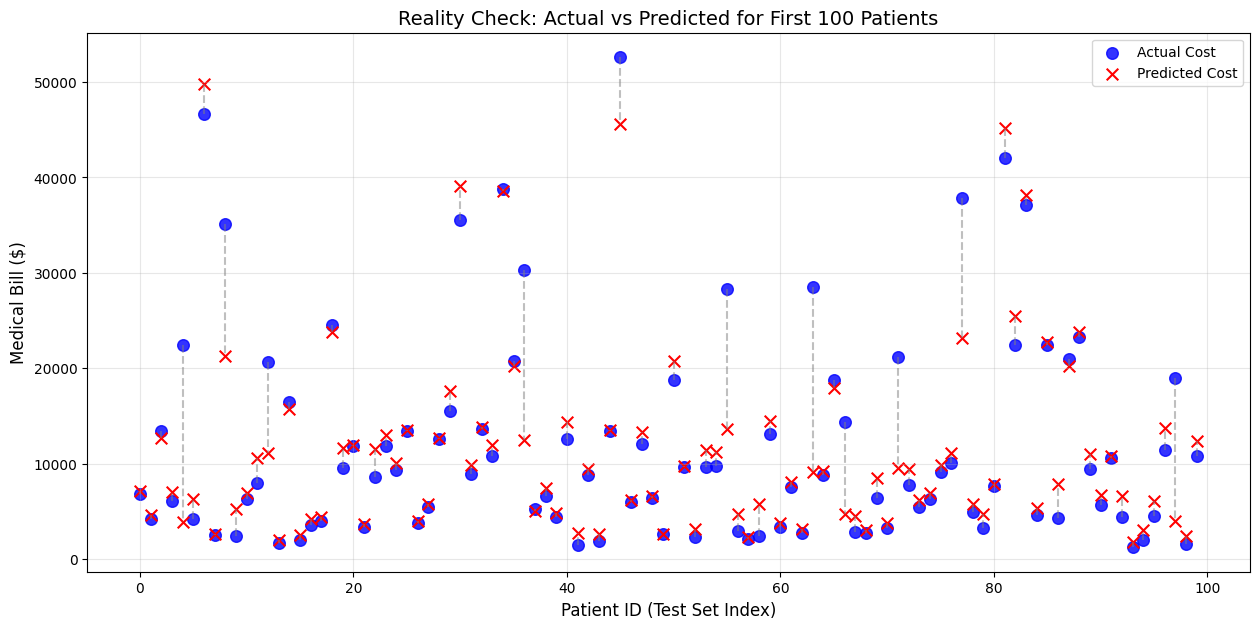

In [80]:
import matplotlib.pyplot as plt

# 1. Select a subset (First 50 Patients) to keep the graph readable
# If we plot all 200+ points, it becomes a mess.
n_view = 100
x_axis = range(n_view)
y_actual_slice = y_test[:n_view].values  # Get first 50 Real Values
y_pred_slice = final_predictions[:n_view] # Get first 50 Predictions

plt.figure(figsize=(15, 7))

# 2. Plot Real Data (Blue Dots)
plt.scatter(x_axis, y_actual_slice, color='blue', label='Actual Cost', s=70, alpha=0.8)

# 3. Plot Predicted Data (Red Crosses)
plt.scatter(x_axis, y_pred_slice, color='red', marker='x', label='Predicted Cost', s=70)

# 4. Draw Vertical Lines (The Error)
# This connects the Blue Dot to the Red Cross for each patient
plt.vlines(x=x_axis, ymin=y_actual_slice, ymax=y_pred_slice, color='gray', alpha=0.5, linestyle='--')

plt.title(f"Reality Check: Actual vs Predicted for First {n_view} Patients", fontsize=14)
plt.xlabel("Patient ID (Test Set Index)", fontsize=12)
plt.ylabel("Medical Bill ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()